# ANOVA Follow-up: FiO2 vs SpO2 Dependency

This notebook analyzes `work/stat_anova.csv` and focuses on subjects with `p < 0.05`.

Goal:
- Identify subjects where ANOVA rejects the null hypothesis (`p < 0.05`).
- Validate whether FiO2 -> SpO2 behaves like a *functional dependency* for those subjects.

Important distinction:
- ANOVA significance means group means differ (evidence of dependence).
- A strict function would require near-zero spread of SpO2 within each FiO2 level (much stronger condition).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from trs_dataset import TRSDataset

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 100)

In [ ]:
anova_path = Path('work') / 'stat_anova.csv'
stat_root = Path('work') / 'stat'

if not stat_root.exists():
    raise FileNotFoundError(f'Missing directory: {stat_root.resolve()}')


loader = TRSDataset(data_dir=stat_root, cache_dir='.')
trs = loader.load_all(max_workers=8, use_cache=True)
trs['patient_id'] = trs['patient_id'].astype(str)
trs = trs[['patient_id', 'time', 'FiO2', 'SpO2']].rename(columns={'FiO2': 'fio2', 'SpO2': 'spo2'})
trs = trs.dropna(subset=['patient_id', 'fio2', 'spo2']).copy()

print(f'Loaded rows from TRSDataset: {len(trs):,}')
display(trs.head())

if not anova_path.exists():
    raise FileNotFoundError(f'Missing file: {anova_path.resolve()}')
anova = pd.read_csv(anova_path)
anova['id'] = anova['id'].astype(str)
print(f'ANOVA rows: {len(anova):,}')
display(anova.head())



Loaded rows from TRSDataset: 2,516,732


,patient_id,time,fio2,spo2
0,10001884,0,0.5,99.0
1,10001884,1,0.5,100.0
2,10001884,2,0.5,95.0
3,10001884,3,0.5,100.0
4,10001884,4,0.5,98.0


ANOVA rows: 14,572


,id,size,n,k,ssb,ssw,f,p,eta2,omega2
0,18376380,101,101,3,138.798667,251.260739,27.068036,4.372200e-10,0.355840,0.340456
1,19755487,78,78,3,84.701908,149.134631,21.298350,4.731293e-08,0.362227,0.342309
2,17900533,105,105,7,168.962702,426.427774,6.471727,8.961053e-06,0.283785,0.238194
3,12863662,79,79,3,80.587511,296.646667,10.323141,1.081137e-04,0.213627,0.190957
4,17302284,194,194,2,11.485516,764.154948,2.885827,9.098188e-02,0.014808,0.009627


,count,percent
all_subjects,14572,100.00
p_lt_0_05,9949,68.27


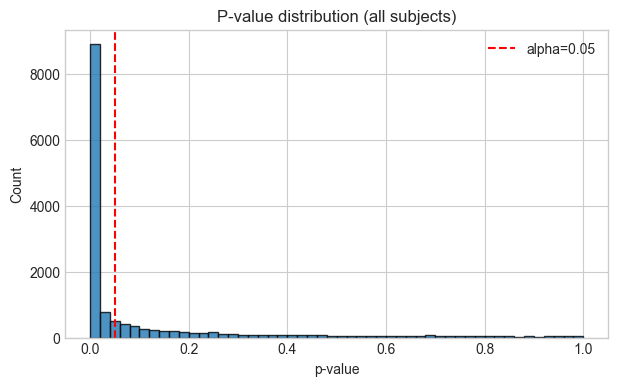

In [19]:
alpha = 0.05
sig = anova[anova['p'] < alpha].copy()

summary = pd.DataFrame({
    'count': [len(anova), len(sig)],
    'percent': [100.0, (len(sig) / len(anova) * 100) if len(anova) else np.nan]
}, index=['all_subjects', 'p_lt_0_05'])
summary['percent'] = summary['percent'].round(2)
display(summary)

plt.figure(figsize=(7, 4))
plt.hist(anova['p'].dropna(), bins=50, edgecolor='black', alpha=0.8)
plt.axvline(alpha, color='red', linestyle='--', label='alpha=0.05')
plt.title('P-value distribution (all subjects)')
plt.xlabel('p-value')
plt.ylabel('Count')
plt.legend()
plt.show()

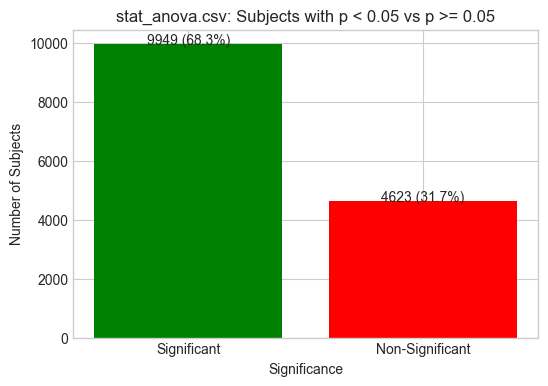

In [43]:
# Plot barplot distribution for significant and non-significant in dep_full based on p-values and 0.05 threshold

def plot_sign_vs_non_sign(significant_count, non_significant_count, title='Significant vs Non-Significant Subjects'):
    # Also plot percentage of significant vs non-significant subjects
    total_count = significant_count + non_significant_count
    significant_percentage = (significant_count / total_count * 100) if total_count > 0 else 0
    non_significant_percentage = (non_significant_count / total_count * 100) if total_count > 0 else 0

    plt.figure(figsize=(6, 4))
    plt.bar(['Significant', 'Non-Significant'], [significant_count, non_significant_count], color=['green', 'red'])
    plt.text(0, significant_count + 1, f'{significant_count} ({significant_percentage:.1f}%)', ha='center')
    plt.text(1, non_significant_count + 1, f'{non_significant_count} ({non_significant_percentage:.1f}%)', ha='center')
    plt.title(title)
    plt.xlabel('Significance')
    plt.ylabel('Number of Subjects')
    plt.show()

significant = anova['p'] < alpha
significant_count = anova[significant]['id'].nunique()
non_significant_count = anova[~significant]['id'].nunique()

plot_sign_vs_non_sign(significant_count, non_significant_count, title='stat_anova.csv: Subjects with p < 0.05 vs p >= 0.05')


In [44]:
trs.head()

,patient_id,time,fio2,spo2
0,10001884,0,0.5,99.0
1,10001884,1,0.5,100.0
2,10001884,2,0.5,95.0
3,10001884,3,0.5,100.0
4,10001884,4,0.5,98.0


In [24]:
subject_data = {
    pid: g[['time', 'fio2', 'spo2']].copy()
    for pid, g in trs.groupby('patient_id', sort=False)
}

def get_subject_df(subject_id: str) -> pd.DataFrame:
    sid = str(subject_id)
    if sid not in subject_data:
        raise FileNotFoundError(f'Subject not found in loaded dataset: {sid}')
    return subject_data[sid]

def dependency_metrics(subject_id: str) -> dict:
    df = get_subject_df(subject_id)
    n = len(df)
    k = df['fio2'].nunique()

    if n < 3 or k < 2:
        return {
            'id': subject_id, 'n_raw': n, 'k_raw': k,
            'eta2_raw': np.nan, 'max_within_std': np.nan, 'mean_within_std': np.nan,
            'spearman_rho': np.nan, 'spearman_p': np.nan,
            'linear_r2': np.nan, 'strict_function': False, 'approx_function': False
        }

    grouped = df.groupby('fio2')['spo2']
    grp_mean = grouped.mean()
    grp_var = grouped.var(ddof=1).fillna(0.0)
    grp_std = grouped.std(ddof=1).fillna(0.0)
    grp_count = grouped.size()

    grand = df['spo2'].mean()
    ssb = ((grp_count * (grp_mean - grand) ** 2)).sum()
    ssw = (((grp_count - 1) * grp_var)).sum()
    sst = ssb + ssw
    eta2_raw = (ssb / sst) if sst > 0 else np.nan

    max_within_std = float(grp_std.max())
    mean_within_std = float(grp_std.mean())
    strict_function = bool(np.isclose(max_within_std, 0.0, atol=1e-12))

    sp = stats.spearmanr(df['fio2'], df['spo2'])
    lr = stats.linregress(df['fio2'], df['spo2'])
    linear_r2 = lr.rvalue ** 2

    # Practical (not strict) rule for approximate functional behavior
    approx_function = bool((eta2_raw >= 0.50) and (max_within_std <= 1.0))

    return {
        'id': subject_id,
        'n_raw': int(n),
        'k_raw': int(k),
        'eta2_raw': float(eta2_raw),
        'max_within_std': max_within_std,
        'mean_within_std': mean_within_std,
        'spearman_rho': float(sp.statistic),
        'spearman_p': float(sp.pvalue),
        'linear_r2': float(linear_r2),
        'strict_function': strict_function,
        'approx_function': approx_function,
    }


In [59]:
import statsmodels.api as sm

def per_patient_nw_test(df_p, maxlags=6):
    # df_p: columns ['time','fio2','spo2'] already cleaned
    df_p = df_p.sort_values('time')
    y = df_p['spo2'].to_numpy()
    X = sm.add_constant(df_p['fio2'].to_numpy())
    ols = sm.OLS(y, X).fit()

    # Newey–West / HAC SE
    ols_nw = ols.get_robustcov_results(cov_type='HAC', maxlags=maxlags)
    # coefficient index 1 corresponds to fio2
    beta1 = ols_nw.params[1]
    pval = ols_nw.pvalues[1]
    return {
        'nw_beta1': beta1,
        'nw_pval': pval,
        'nw_rsquared': ols.rsquared,
        'nw_se': ols_nw.bse[1]
    }

def calc_per_patient_nw_test_by_subject_id(subject_id: str, maxlags=6) -> dict:
    df = get_subject_df(subject_id)
    return per_patient_nw_test(df, maxlags=maxlags)


In [70]:
from tqdm import tqdm
from anova import one_way_anova

records = []
errors = []

# subjects = sig['id']
subjects = trs['patient_id'].unique()
max_proc_subjects = None  # Set to an integer to limit processing for testing, e.g., max_proc_subjects = 10

for index, sid in tqdm(enumerate(subjects), total=len(subjects), desc='Processing subjects', dynamic_ncols=True):
    try:
        df = get_subject_df(sid)

        # basic_metrics = {'id': sid}
        basic_metrics = dependency_metrics(sid)
        one_way_anova_results = one_way_anova( df['fio2'], df['spo2'] ).__dict__
        nw_metrics = calc_per_patient_nw_test_by_subject_id(sid, maxlags=1)
        records.append({**basic_metrics, **one_way_anova_results, **nw_metrics})
    except Exception as exc:
        # print(f'Error processing subject {sid}: {exc}')
        errors.append({'id': sid, 'error': str(exc)})
        # break

    if max_proc_subjects and (len(records) >= max_proc_subjects):
        break

dep = pd.DataFrame(records)
display(dep.head())
# dep_full = sig.merge(dep, on='id', how='left')
# print(f'Significant subjects analyzed: {len(dep):,}')

dep_full = dep
print(f'Subjects analyzed: {len(dep):,}')

print(f'Load/parse errors: {len(errors):,}')
if errors:
    display(pd.DataFrame(errors).head(10))

dep_full.head()

Processing subjects:   5%|▍         | 796/16224 [00:02<00:40, 385.42it/s]C:\Users\jon\AppData\Local\Temp\ipykernel_27472\2418156279.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp = stats.spearmanr(df['fio2'], df['spo2'])
d:\TEMP\KPI\respiroscope\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
Processing subjects:  12%|█▏        | 1896/16224 [00:05<00:38, 372.26it/s]C:\Users\jon\AppData\Local\Temp\ipykernel_27472\2418156279.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  sp = stats.spearmanr(df['fio2'], df['spo2'])
d:\TEMP\KPI\respiroscope\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
Processing subjects:  13%|█▎        | 2143/16224 [0

,id,n_raw,k_raw,eta2_raw,max_within_std,mean_within_std,spearman_rho,spearman_p,linear_r2,strict_function,...,ms_between,ms_within,F,p_value,eta2,omega2,nw_beta1,nw_pval,nw_rsquared,nw_se
0,10001884,198,5,0.102907,6.244998,2.162421,0.082710,0.246683,0.002069,False,...,31.466180,5.685110,5.534841,0.000307,0.102907,0.083924,1.865334,4.660864e-01,0.002069,2.554245
1,10002155,146,4,0.044831,3.126870,2.230444,0.162762,0.049662,0.027733,False,...,21.416922,9.640249,2.221615,0.088256,0.044831,0.024487,4.320594,7.791658e-02,0.027733,2.433360
2,10002430,67,4,0.229549,3.536440,2.526778,0.438288,0.000208,0.217790,False,...,64.283314,10.274237,6.256748,0.000872,0.229549,0.190530,11.357323,5.351916e-08,0.217790,1.846933
3,10002495,117,2,0.005989,2.502173,2.430805,0.112105,0.228829,0.005989,False,...,3.949336,5.699697,0.692903,0.406904,0.005989,-0.002632,1.541011,4.754952e-01,0.005989,2.152507
4,10003046,47,4,0.061190,3.547532,1.306912,0.030673,0.837832,0.017006,False,...,6.595696,7.060122,0.934218,0.432432,0.061190,-0.004217,-1.238429,4.082564e-01,0.017006,1.483554


Subjects analyzed: 14,572
Load/parse errors: 1,652


,id,error
0,10002443,Need at least 2 non-empty groups after filtering.
1,10012853,Need at least 2 non-empty groups after filtering.
2,10016742,Need at least 2 non-empty groups after filtering.
3,10022620,Need at least 2 non-empty groups after filtering.
4,10027704,Need at least 2 non-empty groups after filtering.
5,10041599,Need at least 2 non-empty groups after filtering.
6,10048244,Need at least 2 non-empty groups after filtering.
7,10063848,Need at least 2 non-empty groups after filtering.
8,10074556,Need at least 2 non-empty groups after filtering.
9,10074869,Need at least 2 non-empty groups after filtering.


,id,n_raw,k_raw,eta2_raw,max_within_std,mean_within_std,spearman_rho,spearman_p,linear_r2,strict_function,...,ms_between,ms_within,F,p_value,eta2,omega2,nw_beta1,nw_pval,nw_rsquared,nw_se
0,10001884,198,5,0.102907,6.244998,2.162421,0.082710,0.246683,0.002069,False,...,31.466180,5.685110,5.534841,0.000307,0.102907,0.083924,1.865334,4.660864e-01,0.002069,2.554245
1,10002155,146,4,0.044831,3.126870,2.230444,0.162762,0.049662,0.027733,False,...,21.416922,9.640249,2.221615,0.088256,0.044831,0.024487,4.320594,7.791658e-02,0.027733,2.433360
2,10002430,67,4,0.229549,3.536440,2.526778,0.438288,0.000208,0.217790,False,...,64.283314,10.274237,6.256748,0.000872,0.229549,0.190530,11.357323,5.351916e-08,0.217790,1.846933
3,10002495,117,2,0.005989,2.502173,2.430805,0.112105,0.228829,0.005989,False,...,3.949336,5.699697,0.692903,0.406904,0.005989,-0.002632,1.541011,4.754952e-01,0.005989,2.152507
4,10003046,47,4,0.061190,3.547532,1.306912,0.030673,0.837832,0.017006,False,...,6.595696,7.060122,0.934218,0.432432,0.061190,-0.004217,-1.238429,4.082564e-01,0.017006,1.483554


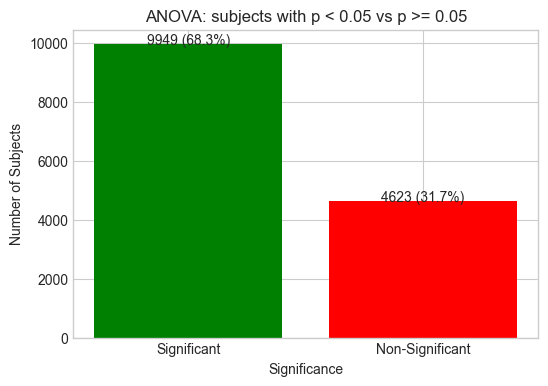

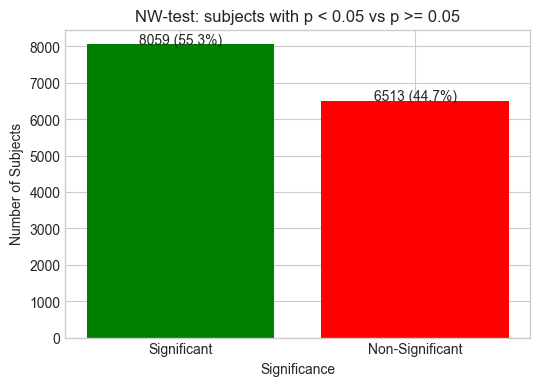

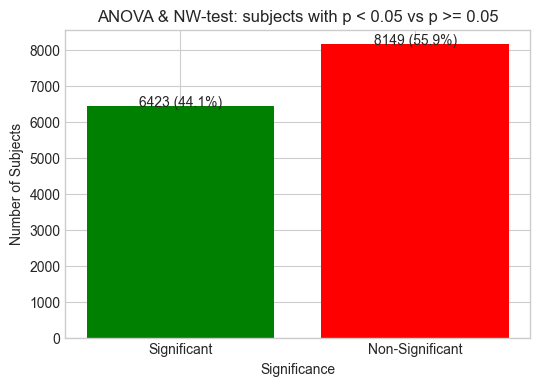

In [71]:
significant_count = (dep_full['p_value'] < alpha).sum()
plot_sign_vs_non_sign(significant_count, len(dep_full) - significant_count, title='ANOVA: subjects with p < 0.05 vs p >= 0.05')

significant_count = (dep_full['nw_pval'] < alpha).sum()
plot_sign_vs_non_sign(significant_count, len(dep_full) - significant_count, title='NW-test: subjects with p < 0.05 vs p >= 0.05')


significant_count = ((dep_full['nw_pval'] < alpha) & (dep_full['p_value'] < alpha)).sum()
plot_sign_vs_non_sign(significant_count, len(dep_full) - significant_count, title='ANOVA & NW-test: subjects with p < 0.05 vs p >= 0.05')

In [72]:
result_summary = pd.DataFrame({
    'metric': [
        'subjects_p_lt_0_05',
        'strict_function_count',
        'approx_function_count',
        'median_eta2_raw',
        'median_max_within_std',
        'median_spearman_rho',
        'median_linear_r2'
    ],
    'value': [
        len(dep_full),
        int(dep_full['strict_function'].sum()),
        int(dep_full['approx_function'].sum()),
        float(dep_full['eta2_raw'].median()),
        float(dep_full['max_within_std'].median()),
        float(dep_full['spearman_rho'].median()),
        float(dep_full['linear_r2'].median())
    ]
})
display(result_summary)

dep_full[['strict_function', 'approx_function']].mean().rename('rate').mul(100).round(2)

,metric,value
0,subjects_p_lt_0_05,14572.000000
1,strict_function_count,6.000000
2,approx_function_count,12.000000
3,median_eta2_raw,0.109820
4,median_max_within_std,2.428725
5,median_spearman_rho,0.066131
6,median_linear_r2,0.037154


strict_function    0.04
approx_function    0.08
Name: rate, dtype: float64

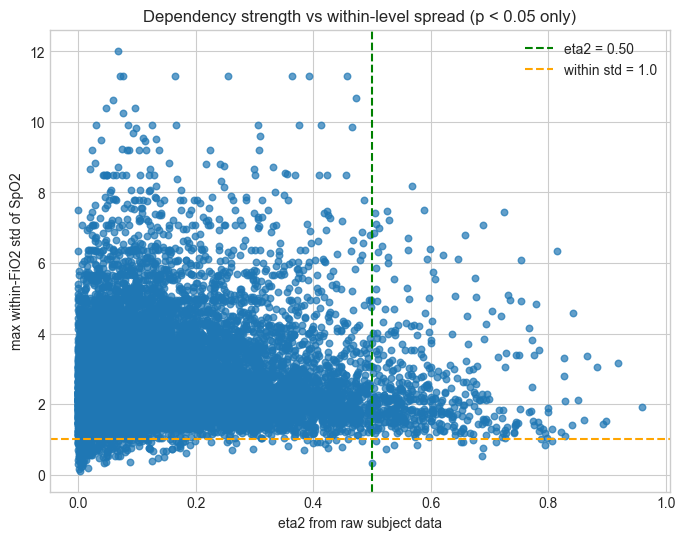

In [73]:
plt.figure(figsize=(8, 6))
plt.scatter(dep_full['eta2_raw'], dep_full['max_within_std'], alpha=0.7, s=22)
plt.axvline(0.50, color='green', linestyle='--', label='eta2 = 0.50')
plt.axhline(1.0, color='orange', linestyle='--', label='within std = 1.0')
plt.xlabel('eta2 from raw subject data')
plt.ylabel('max within-FiO2 std of SpO2')
plt.title('Dependency strength vs within-level spread (p < 0.05 only)')
plt.legend()
plt.show()

In [76]:
cols = [
    'id', 'n_raw', 'k', 'F', 'p_value', 'eta2', 'omega2',
    'eta2_raw', 'max_within_std', 'spearman_rho', 'linear_r2',
    'strict_function', 'approx_function'
]
display(dep_full.dropna().sort_values(['strict_function', 'approx_function', 'eta2_raw'], ascending=[False, False, False])[cols].head(25))

,id,n_raw,k,F,p_value,eta2,omega2,eta2_raw,max_within_std,spearman_rho,linear_r2,strict_function,approx_function
548,10357649,156,3,319.050650,2.595010e-55,0.806599,0.803055,0.806599,0.961321,-0.057113,0.003418,False,True
105,10067480,93,3,174.495790,1.072468e-31,0.794985,0.788632,0.794985,0.832050,0.824597,0.089570,False,True
13978,19601036,48,3,55.454397,7.205976e-13,0.711370,0.694090,0.711370,0.933387,0.810233,0.138665,False,True
7866,15413563,101,3,108.577573,1.387976e-25,0.689042,0.680537,0.689042,0.757776,0.707526,0.561613,False,True
11262,17688843,138,3,148.079569,9.109441e-35,0.686891,0.680673,0.686891,0.542886,-0.061399,0.397048,False,True
10446,17147211,43,3,41.068510,2.014899e-10,0.672499,0.650796,0.672499,0.989361,0.820063,0.528586,False,True
656,10452075,75,4,44.968466,2.127454e-16,0.655181,0.637516,0.655181,0.913740,0.826604,0.104588,False,True
13513,19286193,66,2,119.379219,2.867204e-16,0.650996,0.642042,0.650996,0.933459,0.769986,0.650996,False,True
3155,12163417,92,3,60.481248,2.585523e-17,0.576115,0.563904,0.576115,0.833446,0.784902,0.495583,False,True
10288,17031372,65,2,72.932414,4.071012e-12,0.536534,0.525313,0.536534,0.838168,0.626347,0.536534,False,True


C:\Users\jon\AppData\Local\Temp\ipykernel_27472\3821039668.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(by_level, labels=[str(x) for x in levels], showfliers=False)


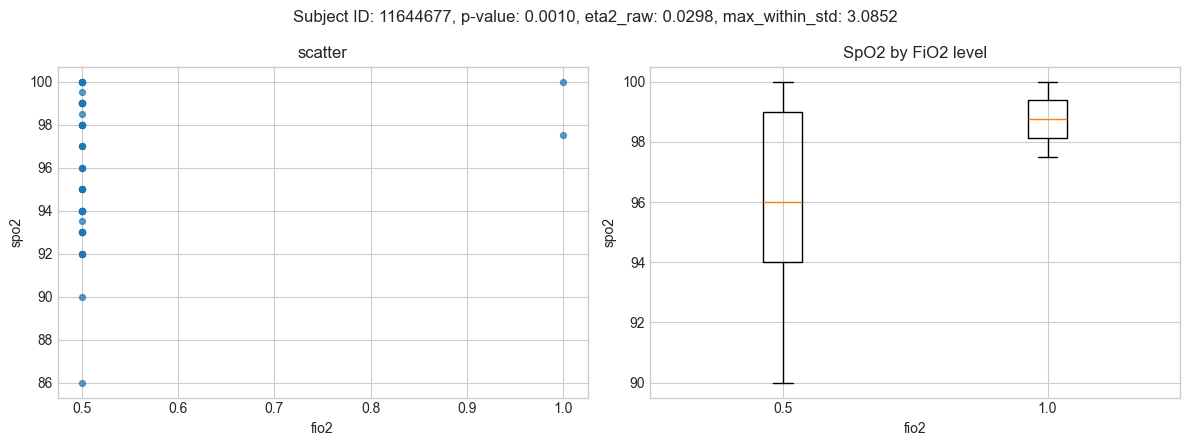

C:\Users\jon\AppData\Local\Temp\ipykernel_27472\3821039668.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(by_level, labels=[str(x) for x in levels], showfliers=False)


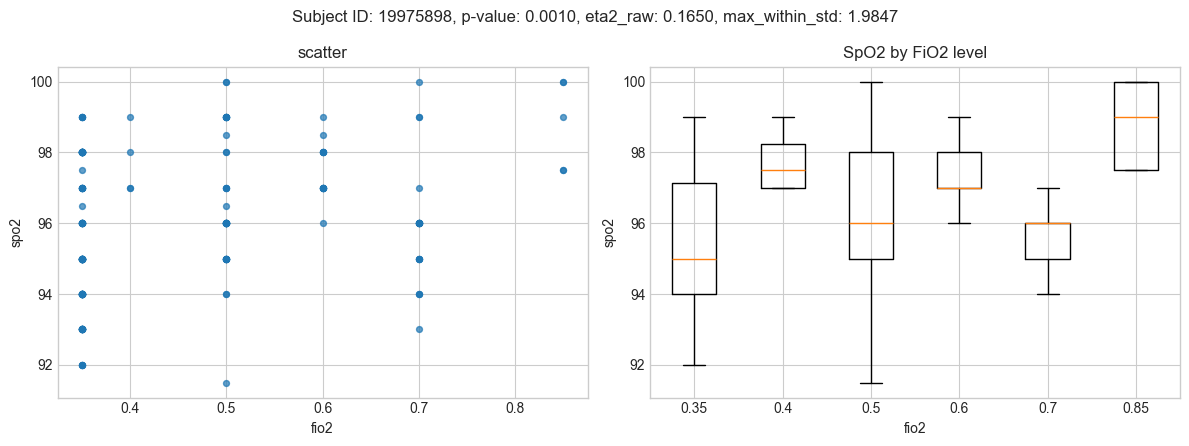

C:\Users\jon\AppData\Local\Temp\ipykernel_27472\3821039668.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(by_level, labels=[str(x) for x in levels], showfliers=False)


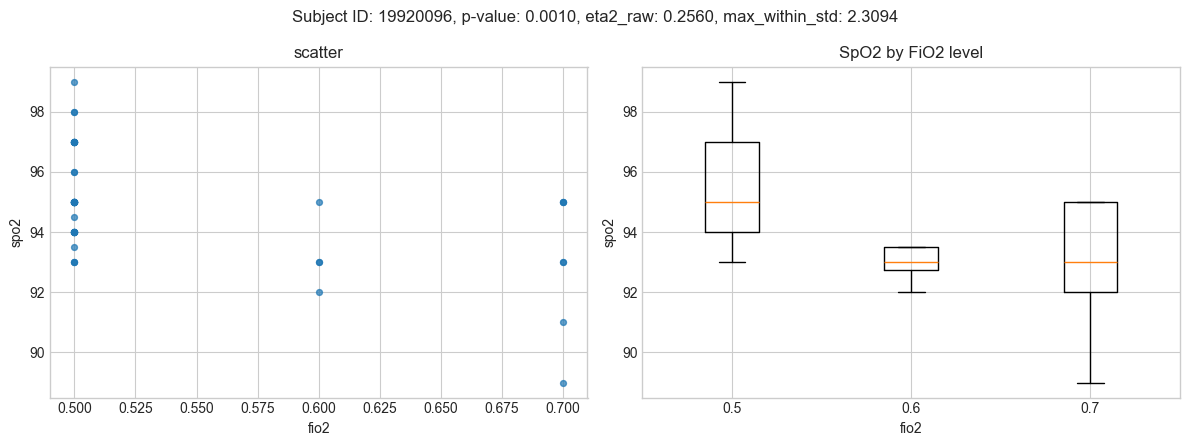

C:\Users\jon\AppData\Local\Temp\ipykernel_27472\3821039668.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(by_level, labels=[str(x) for x in levels], showfliers=False)


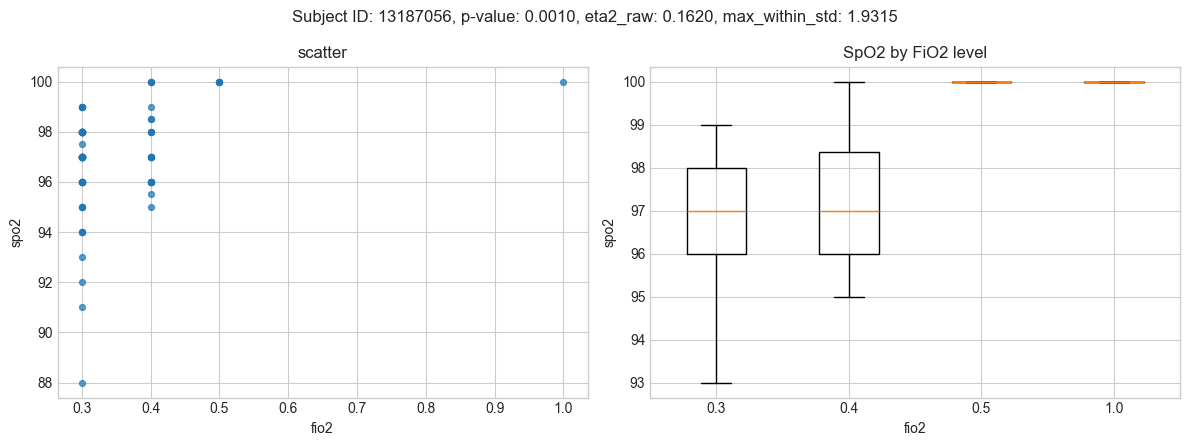

C:\Users\jon\AppData\Local\Temp\ipykernel_27472\3821039668.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(by_level, labels=[str(x) for x in levels], showfliers=False)


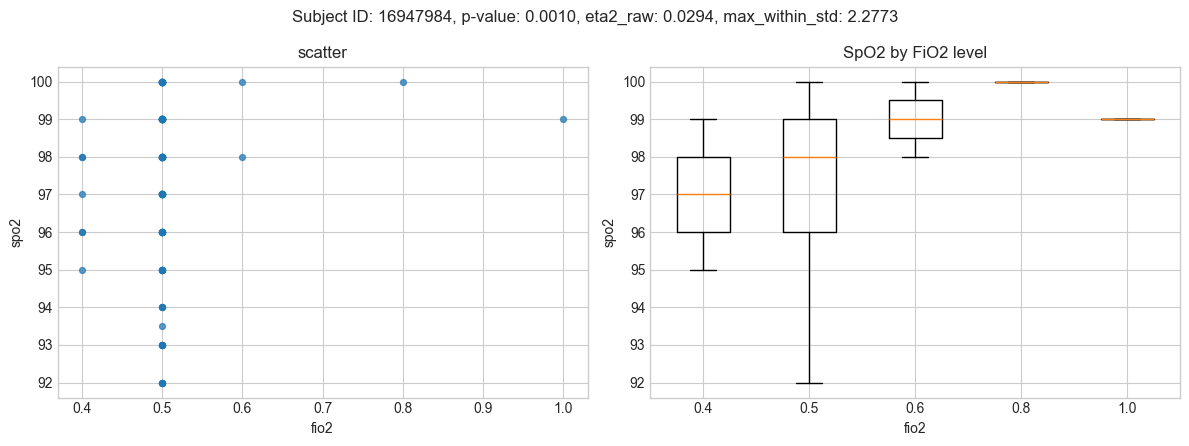

In [81]:
def plot_subject(subject_id: str, title: str = None):
    d = get_subject_df(subject_id)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    fig.suptitle(title if title else f'Subject ID: {subject_id}', fontsize=12)

    axes[0].scatter(d['fio2'], d['spo2'], alpha=0.7, s=18)
    axes[0].set_title(f'scatter')
    axes[0].set_xlabel('fio2')
    axes[0].set_ylabel('spo2')

    levels = sorted(d['fio2'].unique())
    by_level = [d.loc[d['fio2'] == x, 'spo2'].values for x in levels]
    axes[1].boxplot(by_level, labels=[str(x) for x in levels], showfliers=False)
    axes[1].set_title(f'SpO2 by FiO2 level')
    axes[1].set_xlabel('fio2')
    axes[1].set_ylabel('spo2')

    fig.tight_layout()
    plt.show()

# Plot some samples
p_value_col = 'nw_pval' # 'p_value'
to_plot = dep_full[dep_full[p_value_col] > 0.001].copy()
for idx, row in to_plot.sort_values(p_value_col).head(5).iterrows():
    print()
    plot_subject(row['id'], title=f"Subject ID: {row['id']}, p-value: {row[p_value_col]:.4f}, eta2_raw: {row['eta2_raw']:.4f}, max_within_std: {row['max_within_std']:.4f}")

## Interpretation template

Use the computed summary values above to conclude:
- If `strict_function_count` is near zero, FiO2 -> SpO2 is not a strict function for most significant subjects.
- If many subjects have high `eta2_raw` and low within-FiO2 spread, there is strong practical dependency (but still noisy).
- ANOVA `p < 0.05` supports effect on means, not deterministic one-to-one mapping.